In [ ]:
!pip install kagglehub

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import kagglehub

path = kagglehub.dataset_download("kyr7plus/emg-4")
print("Dataset Path:", path)

import os
files = os.listdir(path)
print(files)

100%|██████████| 868k/868k [00:00<00:00, 100MB/s]

Extracting files...
Dataset Path: /root/.cache/kagglehub/datasets/kyr7plus/emg-4/versions/2
['2.csv', '1.csv', '0.csv', '3.csv']


In [ ]:
data = []
labels = []

for i, file in enumerate(files):
    file_path = os.path.join(path, file)
    temp = pd.read_csv(file_path, header=None)

    data.append(temp)
    labels.extend([i] * len(temp))   # assign label

# Combine all
X = pd.concat(data, ignore_index=True)
y = pd.Series(labels)

In [ ]:
print(X.shape)
print(y.value_counts())

(11678, 65)
0    2943
3    2922
2    2910
1    2903
Name: count, dtype: int64


In [ ]:
X['label'] = y
X = X.sample(frac=1, random_state=42).reset_index(drop=True)

y = X['label']
X = X.drop('label', axis=1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Logistic Regression: 1.0


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN:", accuracy_score(y_test, y_pred_knn))

KNN: 0.7628424657534246


In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))

Decision Tree: 1.0


In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Random Forest: 1.0


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       581
           2       1.00      1.00      1.00       582
           3       1.00      1.00      1.00       584

    accuracy                           1.00      2336
   macro avg       1.00      1.00      1.00      2336
weighted avg       1.00      1.00      1.00      2336



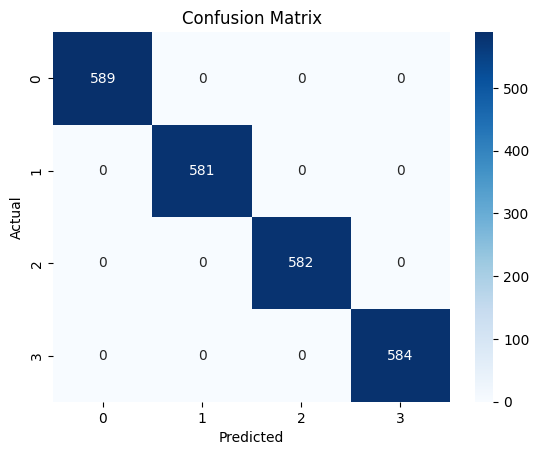

In [ ]:
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 1.0000
KNN: 0.7628
Decision Tree: 1.0000
Random Forest: 1.0000


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [ ]:
# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
n_classes = y_test_bin.shape[1]

In [ ]:
# Logistic Regression
y_score_lr = lr.predict_proba(X_test)

# KNN
y_score_knn = knn.predict_proba(X_test)

# Decision Tree
y_score_dt = dt.predict_proba(X_test)

# Random Forest
y_score_rf = rf.predict_proba(X_test)

In [ ]:
import matplotlib.pyplot as plt

def plot_roc(y_test_bin, y_score, model_name):
    plt.figure()

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

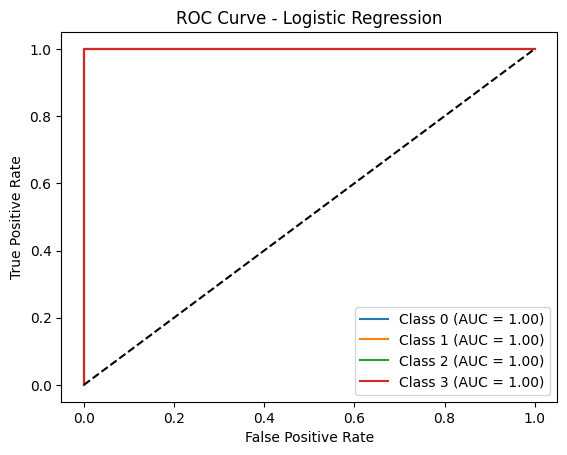

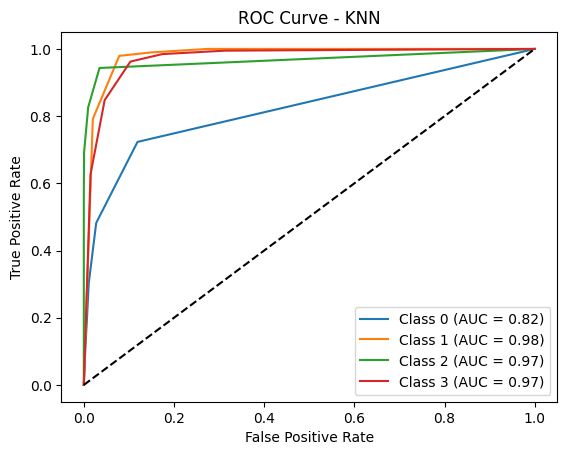

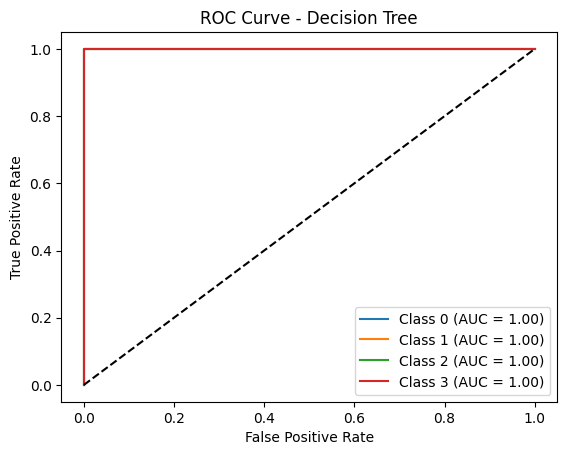

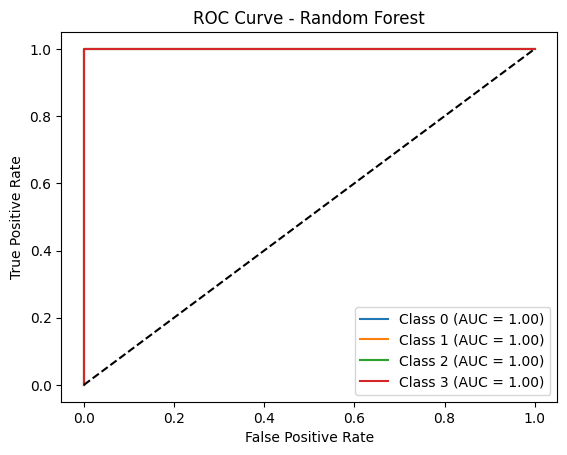

In [ ]:
plot_roc(y_test_bin, y_score_lr, "Logistic Regression")
plot_roc(y_test_bin, y_score_knn, "KNN")
plot_roc(y_test_bin, y_score_dt, "Decision Tree")
plot_roc(y_test_bin, y_score_rf, "Random Forest")

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm = SVC(kernel='rbf', probability=True)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

from sklearn.metrics import accuracy_score
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.9935787671232876


In [ ]:
y_score_svm = svm.predict_proba(X_test)

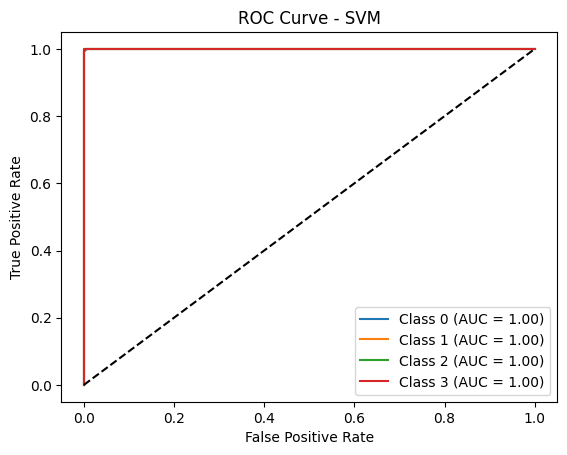

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
n_classes = y_test_bin.shape[1]

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_svm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n🔹 {model_name}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("Classification Report:\n")
    print(classification_report(y_test, y_pred))


🔹 Logistic Regression
Confusion Matrix:
 [[589   0   0   0]
 [  0 581   0   0]
 [  0   0 582   0]
 [  0   0   0 584]]


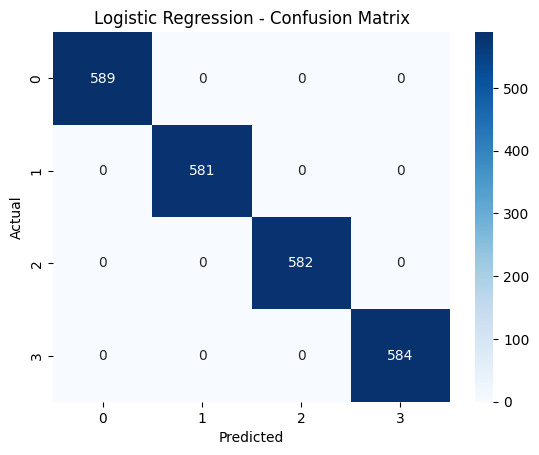

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       581
           2       1.00      1.00      1.00       582
           3       1.00      1.00      1.00       584

    accuracy                           1.00      2336
   macro avg       1.00      1.00      1.00      2336
weighted avg       1.00      1.00      1.00      2336


🔹 KNN
Confusion Matrix:
 [[236 170   0 183]
 [  0 579   1   1]
 [ 36 141 405   0]
 [  3  16   3 562]]


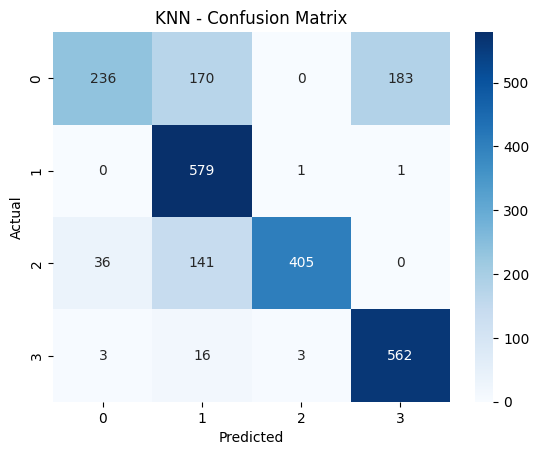

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.40      0.55       589
           1       0.64      1.00      0.78       581
           2       0.99      0.70      0.82       582
           3       0.75      0.96      0.85       584

    accuracy                           0.76      2336
   macro avg       0.81      0.76      0.75      2336
weighted avg       0.81      0.76      0.75      2336


🔹 Decision Tree
Confusion Matrix:
 [[589   0   0   0]
 [  0 581   0   0]
 [  0   0 582   0]
 [  0   0   0 584]]


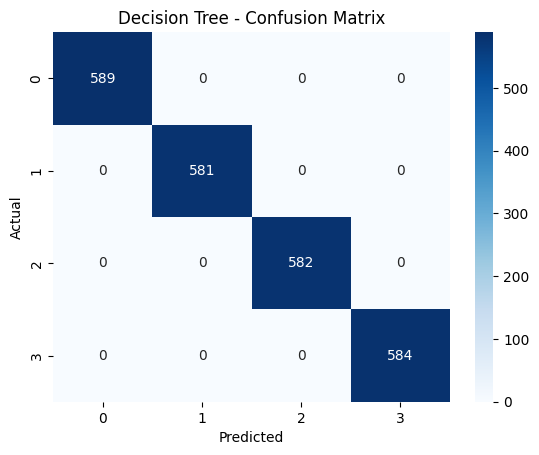

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       581
           2       1.00      1.00      1.00       582
           3       1.00      1.00      1.00       584

    accuracy                           1.00      2336
   macro avg       1.00      1.00      1.00      2336
weighted avg       1.00      1.00      1.00      2336


🔹 Random Forest
Confusion Matrix:
 [[589   0   0   0]
 [  0 581   0   0]
 [  0   0 582   0]
 [  0   0   0 584]]


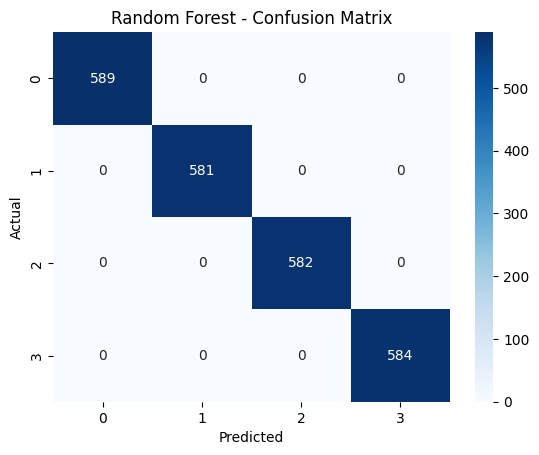

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       589
           1       1.00      1.00      1.00       581
           2       1.00      1.00      1.00       582
           3       1.00      1.00      1.00       584

    accuracy                           1.00      2336
   macro avg       1.00      1.00      1.00      2336
weighted avg       1.00      1.00      1.00      2336



In [ ]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")



🔹 SVM
Confusion Matrix:
 [[581   0   8   0]
 [  0 580   1   0]
 [  0   0 582   0]
 [  2   0   4 578]]


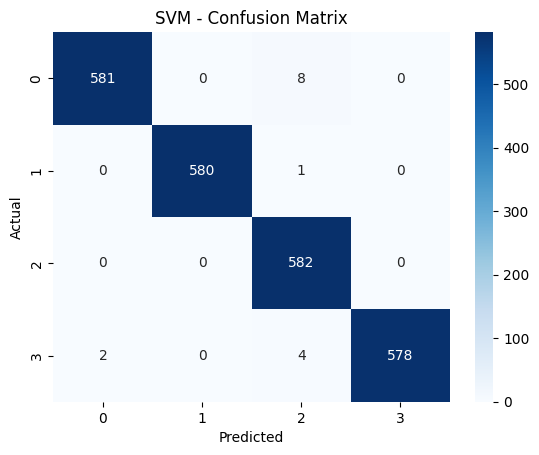

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       589
           1       1.00      1.00      1.00       581
           2       0.98      1.00      0.99       582
           3       1.00      0.99      0.99       584

    accuracy                           0.99      2336
   macro avg       0.99      0.99      0.99      2336
weighted avg       0.99      0.99      0.99      2336



In [ ]:
evaluate_model(y_test, y_pred_svm, "SVM")